In [1]:
# CELL 1: SETUP & IMPORTS
import os
import time
import json
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Buat folder untuk menyimpan semua hasil agar tidak berantakan
SAVE_DIR = "results_exp3"
os.makedirs(SAVE_DIR, exist_ok=True)

# Cek ketersediaan GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")
if torch.cuda.is_available():
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")

Menggunakan device: cuda
Nama GPU: NVIDIA GeForce RTX 5070


In [2]:
# CELL 2: FOCAL LOSS
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [3]:
# CELL 3: DATASET & STRATIFIED K-FOLD (UPDATED LOCAL PATHS)
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold

# 1. Kunci Lokasi Data Lokal
data_dir = r"C:\Users\asfan\Data\ham10000\full"
csv_path = r"C:\Users\asfan\Data\ham10000\HAM10000_metadata.csv"

# 2. Baca Metadata dan Petakan Kelas
df = pd.read_csv(csv_path)
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
class_to_idx = {c: i for i, c in enumerate(class_names)}

# Mapping kelas teks ('dx') menjadi indeks angka
df['label'] = df['dx'].map(class_to_idx)

# Membangun full path untuk setiap gambar secara otomatis
# Asumsi format gambar adalah .jpg dan nama file sama dengan image_id
df['image_path'] = df.apply(lambda row: os.path.join(data_dir, row['dx'], f"{row['image_id']}.jpg"), axis=1)

# Verifikasi path (Cek apakah gambar pertama benar-benar ada)
print(f"Total data: {len(df)}")
print(f"Contoh path gambar: {df.iloc[0]['image_path']}")
if not os.path.exists(df.iloc[0]['image_path']):
    print("WARNING: Path gambar tidak ditemukan! Pastikan ekstensi .jpg atau nama folder sesuai.")

# 3. Class Dataset Kustom
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# 4. Augmentasi Data
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. Persiapan Stratified 5-Fold
X = df['image_path'].values
y = df['label'].values
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Dataset dan Stratified K-Fold siap!")

Total data: 10015
Contoh path gambar: C:\Users\asfan\Data\ham10000\full\bkl\ISIC_0027419.jpg
Dataset dan Stratified K-Fold siap!


In [4]:
# CELL 4 (REVISI UNTUK EXP 3): ConvNeXt + CBAM Attention
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
           
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv1(x)
        return self.sigmoid(x)

class CBAM(nn.Module):
    def __init__(self, channels, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(channels, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

class ConvNeXt_CBAM_Attention(nn.Module):
    def __init__(self, num_classes=7):
        super(ConvNeXt_CBAM_Attention, self).__init__()
        convnext = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        self.features = convnext.features
        
        # Injeksi CBAM
        self.cbam = CBAM(channels=768)
        
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(1),
            nn.LayerNorm(768, eps=1e-6),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x) # Proses Channel + Spatial secara berurutan
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

In [5]:
# CELL 5: TRAINING ENGINE WITH METRIC TRACKING & EPOCH TIMER
def train_model(fold, model, train_loader, val_loader, criterion, optimizer, num_epochs=50):
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    start_time_total = time.time()
    torch.cuda.reset_peak_memory_stats()
    
    for epoch in range(num_epochs):
        epoch_start_time = time.time() # Mulai hitung waktu per epoch
        
        # --- TRAINING PHASE ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            total += labels.size(0)
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct.double() / total
        
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)
                val_total += labels.size(0)
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct.double() / val_total
        
        # Hitung durasi epoch
        epoch_end_time = time.time()
        duration = epoch_end_time - epoch_start_time
        minutes = int(duration // 60)
        seconds = int(duration % 60)
        
        # Simpan metrik ke history
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['val_acc'].append(epoch_val_acc.item())
        
        # Output sesuai permintaan (ditambah durasi)
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f} - {minutes} menit {seconds} detik")
        
        # Simpan model terbaik (.pth) - Update ke exp3
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            model_save_path = os.path.join(SAVE_DIR, f"exp3_fold{fold}_best_model.pth")
            torch.save(model.state_dict(), model_save_path)
            
    # Kalkulasi performa total
    end_time_total = time.time()
    training_time_total = end_time_total - start_time_total
    max_memory = torch.cuda.max_memory_allocated() / (1024 ** 2) 
    
    # Simpan history ke JSON
    with open(os.path.join(SAVE_DIR, f"exp3_fold{fold}_history.json"), 'w') as f:
        json.dump(history, f)
        
    return history, training_time_total, max_memory

In [6]:
# CELL 6: EVALUATION & REPORTING
def evaluate_and_plot(fold, model, val_loader, history, training_time, max_memory, class_names):
    # Load model terbaik
    model.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"exp3_fold{fold}_best_model.pth")))
    model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 1. Classification Report & Metrics
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(SAVE_DIR, f"exp3_fold{fold}_classification_report.csv"))
    
    # Simpan resource metrik
    resource_log = {
        'training_time_seconds': training_time,
        'max_gpu_memory_mb': max_memory,
        'overall_accuracy': accuracy_score(all_labels, all_preds)
    }
    with open(os.path.join(SAVE_DIR, f"exp3_fold{fold}_resources.json"), 'w') as f:
        json.dump(resource_log, f)
        
    # 2. Plot Loss & Accuracy Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_title(f'Loss Curve - Fold {fold}')
    ax1.legend()
    
    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_title(f'Accuracy Curve - Fold {fold}')
    ax2.legend()
    plt.savefig(os.path.join(SAVE_DIR, f"exp3_fold{fold}_learning_curves.png"))
    plt.show()
    
    # 3. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(os.path.join(SAVE_DIR, f"exp3_fold{fold}_confusion_matrix.png"))
    plt.show()
    
    print(f"Semua log dan grafik untuk Fold {fold} berhasil disimpan di folder: {SAVE_DIR}")

# CONTOH EKSEKUSI (Bisa diletakkan di dalam loop Stratified K-Fold)
# class_names = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
# criterion = FocalLoss(gamma=2)
# optimizer = optim.Adam(model.parameters(), lr=1e-4)
# history, t_time, max_mem = train_model(fold=1, model=model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer)
# evaluate_and_plot(fold=1, model=model, val_loader=val_loader, history=history, training_time=t_time, max_memory=max_mem, class_names=class_names)

Mulai Eksperimen 3: ConvNeXt + CBAM + Focal Loss
Menyimpan di folder: results_exp3

---> Memulai Fold 1 <---
Epoch 1/50 - Train Loss: 0.3924 Acc: 0.7493 | Val Loss: 0.2357 Acc: 0.8188 - 2 menit 14 detik
Epoch 2/50 - Train Loss: 0.2186 Acc: 0.8342 | Val Loss: 0.1800 Acc: 0.8552 - 2 menit 11 detik
Epoch 3/50 - Train Loss: 0.1539 Acc: 0.8712 | Val Loss: 0.1817 Acc: 0.8542 - 2 menit 12 detik
Epoch 4/50 - Train Loss: 0.1068 Acc: 0.9031 | Val Loss: 0.1664 Acc: 0.8747 - 2 menit 11 detik
Epoch 5/50 - Train Loss: 0.0865 Acc: 0.9249 | Val Loss: 0.1536 Acc: 0.8722 - 2 menit 11 detik
Epoch 6/50 - Train Loss: 0.0550 Acc: 0.9436 | Val Loss: 0.1402 Acc: 0.8777 - 2 menit 10 detik
Epoch 7/50 - Train Loss: 0.0515 Acc: 0.9435 | Val Loss: 0.1281 Acc: 0.8997 - 2 menit 11 detik
Epoch 8/50 - Train Loss: 0.0394 Acc: 0.9589 | Val Loss: 0.1712 Acc: 0.8737 - 2 menit 10 detik
Epoch 9/50 - Train Loss: 0.0393 Acc: 0.9582 | Val Loss: 0.1344 Acc: 0.8857 - 2 menit 10 detik
Epoch 10/50 - Train Loss: 0.0261 Acc: 0.9724 

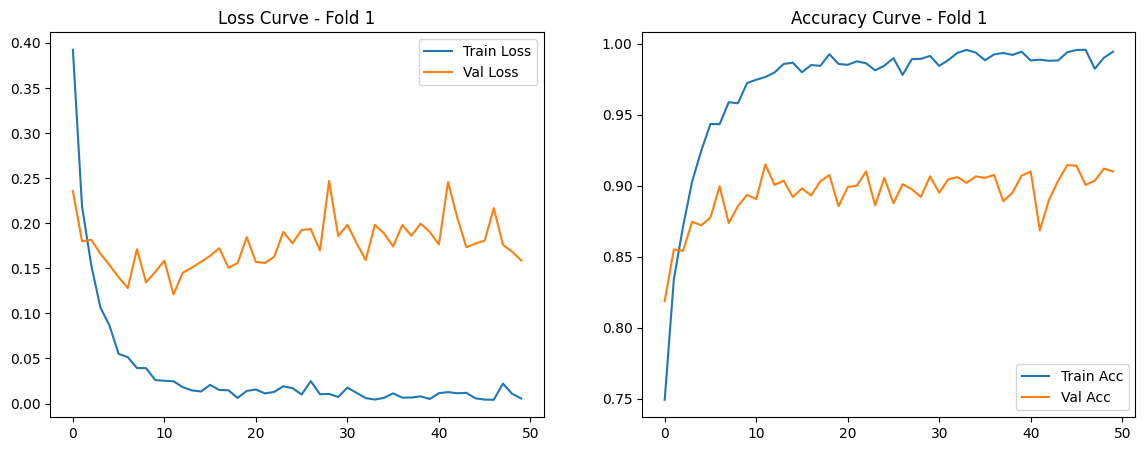

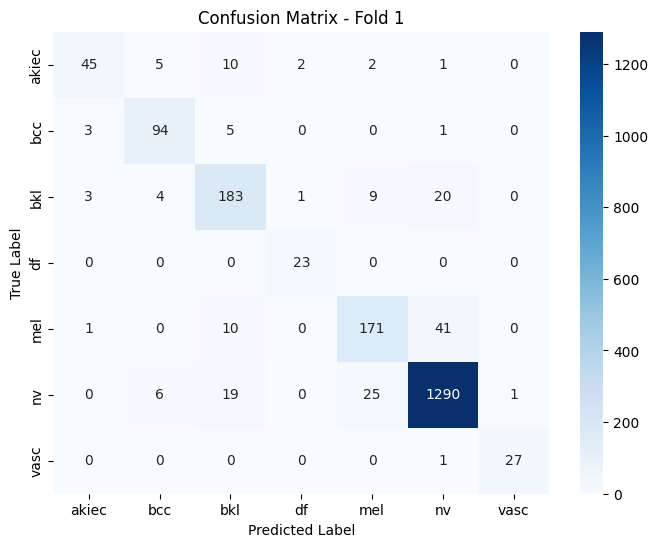

Semua log dan grafik untuk Fold 1 berhasil disimpan di folder: results_exp3

---> Memulai Fold 2 <---
Epoch 1/50 - Train Loss: 0.4125 Acc: 0.7400 | Val Loss: 0.2454 Acc: 0.8183 - 2 menit 10 detik
Epoch 2/50 - Train Loss: 0.2241 Acc: 0.8259 | Val Loss: 0.1944 Acc: 0.8447 - 2 menit 11 detik
Epoch 3/50 - Train Loss: 0.1552 Acc: 0.8699 | Val Loss: 0.1828 Acc: 0.8572 - 2 menit 11 detik
Epoch 4/50 - Train Loss: 0.1143 Acc: 0.8934 | Val Loss: 0.1695 Acc: 0.8682 - 2 menit 12 detik
Epoch 5/50 - Train Loss: 0.0824 Acc: 0.9217 | Val Loss: 0.1546 Acc: 0.8907 - 2 menit 11 detik
Epoch 6/50 - Train Loss: 0.0674 Acc: 0.9362 | Val Loss: 0.1322 Acc: 0.8847 - 2 menit 11 detik
Epoch 7/50 - Train Loss: 0.0513 Acc: 0.9506 | Val Loss: 0.1365 Acc: 0.8952 - 2 menit 11 detik
Epoch 8/50 - Train Loss: 0.0344 Acc: 0.9652 | Val Loss: 0.1524 Acc: 0.8807 - 2 menit 11 detik
Epoch 9/50 - Train Loss: 0.0325 Acc: 0.9636 | Val Loss: 0.1611 Acc: 0.8922 - 2 menit 11 detik
Epoch 10/50 - Train Loss: 0.0240 Acc: 0.9725 | Val L

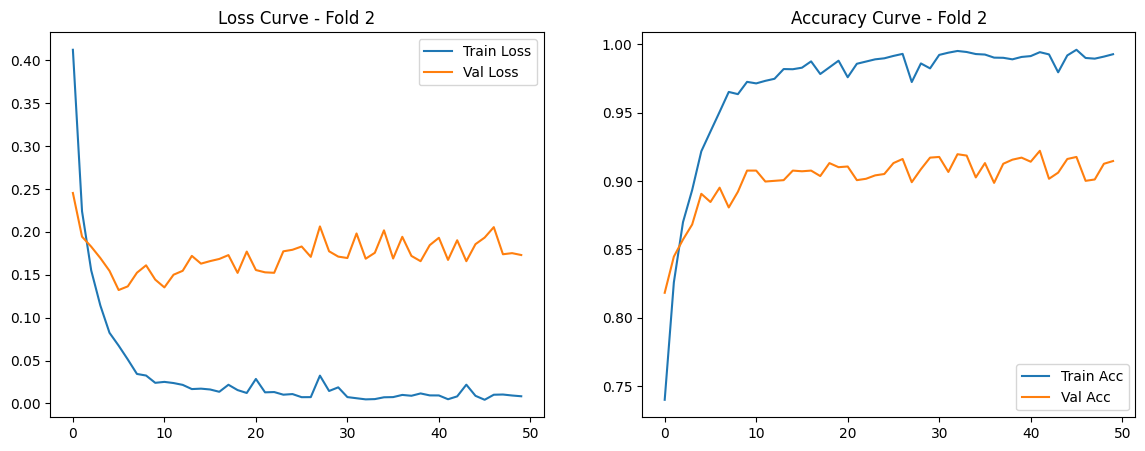

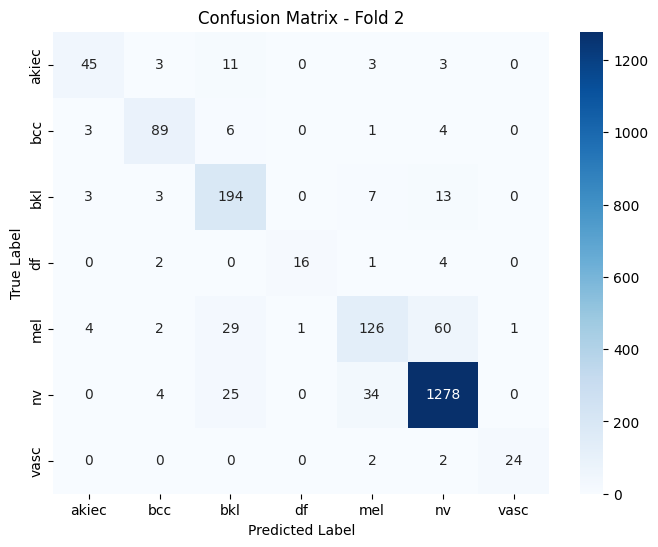

Semua log dan grafik untuk Fold 2 berhasil disimpan di folder: results_exp3

---> Memulai Fold 3 <---
Epoch 1/50 - Train Loss: 0.3783 Acc: 0.7572 | Val Loss: 0.3536 Acc: 0.7843 - 2 menit 9 detik
Epoch 2/50 - Train Loss: 0.2058 Acc: 0.8377 | Val Loss: 0.1919 Acc: 0.8462 - 2 menit 10 detik
Epoch 3/50 - Train Loss: 0.1405 Acc: 0.8809 | Val Loss: 0.1751 Acc: 0.8657 - 2 menit 10 detik
Epoch 4/50 - Train Loss: 0.0993 Acc: 0.9049 | Val Loss: 0.1484 Acc: 0.8742 - 2 menit 10 detik
Epoch 5/50 - Train Loss: 0.0725 Acc: 0.9305 | Val Loss: 0.1488 Acc: 0.8797 - 2 menit 9 detik
Epoch 6/50 - Train Loss: 0.0585 Acc: 0.9401 | Val Loss: 0.2004 Acc: 0.8632 - 2 menit 10 detik
Epoch 7/50 - Train Loss: 0.0495 Acc: 0.9480 | Val Loss: 0.1515 Acc: 0.8872 - 2 menit 10 detik
Epoch 8/50 - Train Loss: 0.0321 Acc: 0.9632 | Val Loss: 0.1460 Acc: 0.9001 - 2 menit 11 detik
Epoch 9/50 - Train Loss: 0.0294 Acc: 0.9668 | Val Loss: 0.1520 Acc: 0.8967 - 2 menit 10 detik
Epoch 10/50 - Train Loss: 0.0257 Acc: 0.9730 | Val Los

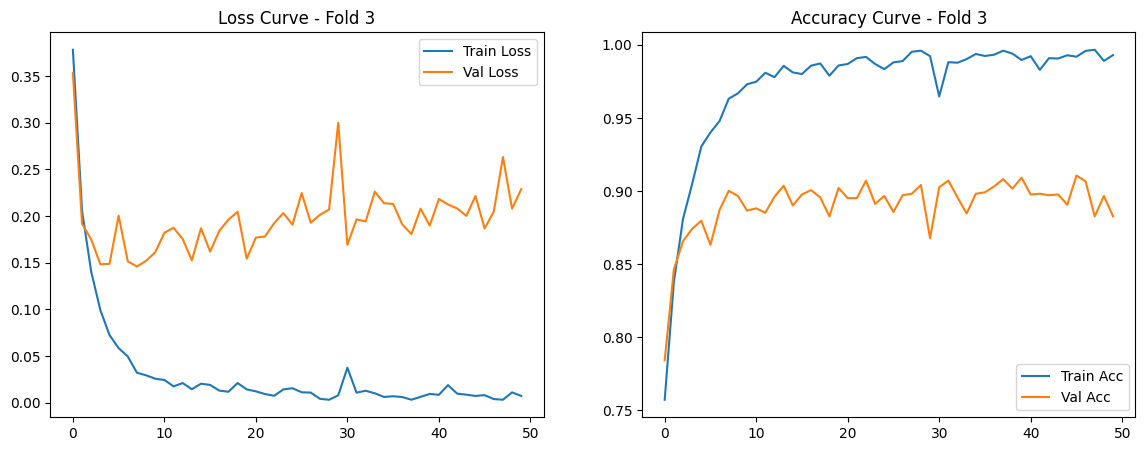

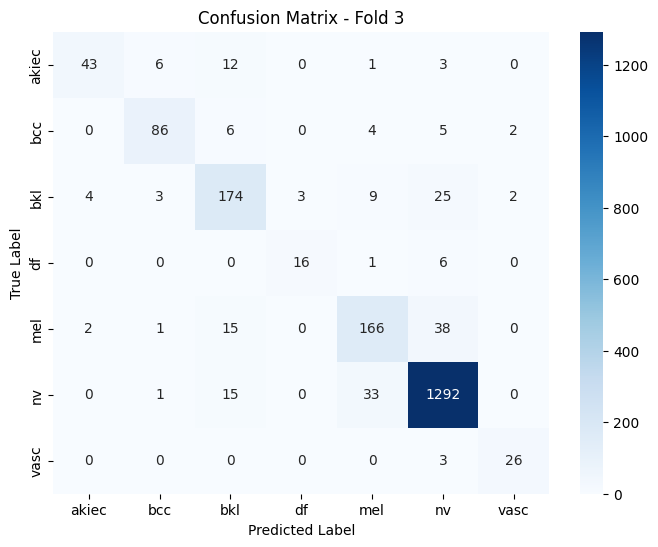

Semua log dan grafik untuk Fold 3 berhasil disimpan di folder: results_exp3

---> Memulai Fold 4 <---
Epoch 1/50 - Train Loss: 0.4090 Acc: 0.7436 | Val Loss: 0.2468 Acc: 0.8103 - 2 menit 9 detik
Epoch 2/50 - Train Loss: 0.2168 Acc: 0.8391 | Val Loss: 0.2371 Acc: 0.8148 - 2 menit 10 detik
Epoch 3/50 - Train Loss: 0.1523 Acc: 0.8697 | Val Loss: 0.1795 Acc: 0.8522 - 2 menit 9 detik
Epoch 4/50 - Train Loss: 0.1077 Acc: 0.9035 | Val Loss: 0.1482 Acc: 0.8772 - 2 menit 9 detik
Epoch 5/50 - Train Loss: 0.0954 Acc: 0.9129 | Val Loss: 0.1279 Acc: 0.8927 - 2 menit 9 detik
Epoch 6/50 - Train Loss: 0.0571 Acc: 0.9410 | Val Loss: 0.1281 Acc: 0.8837 - 2 menit 10 detik
Epoch 7/50 - Train Loss: 0.0488 Acc: 0.9496 | Val Loss: 0.1531 Acc: 0.8827 - 2 menit 10 detik
Epoch 8/50 - Train Loss: 0.0405 Acc: 0.9562 | Val Loss: 0.1396 Acc: 0.8967 - 2 menit 9 detik
Epoch 9/50 - Train Loss: 0.0310 Acc: 0.9682 | Val Loss: 0.2433 Acc: 0.8527 - 2 menit 10 detik
Epoch 10/50 - Train Loss: 0.0291 Acc: 0.9689 | Val Loss: 

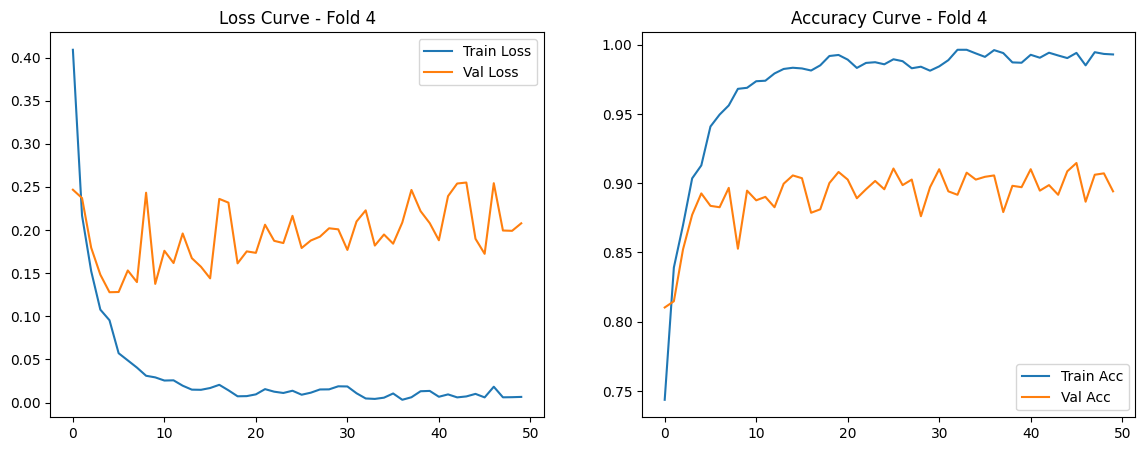

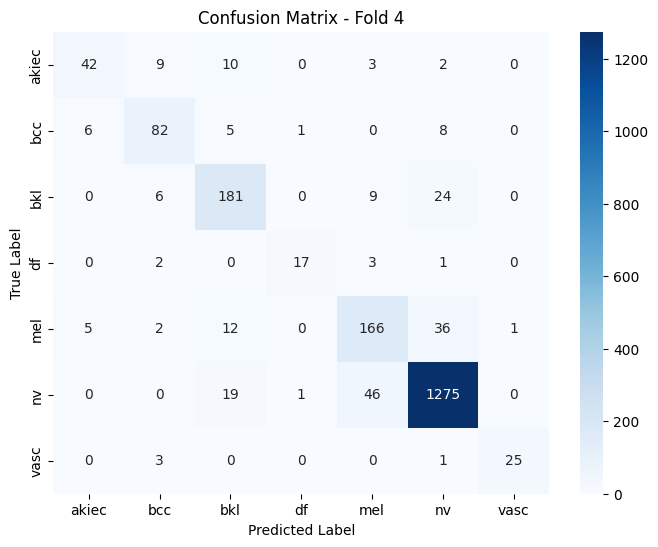

Semua log dan grafik untuk Fold 4 berhasil disimpan di folder: results_exp3

---> Memulai Fold 5 <---
Epoch 1/50 - Train Loss: 0.3942 Acc: 0.7559 | Val Loss: 0.2557 Acc: 0.8028 - 2 menit 9 detik
Epoch 2/50 - Train Loss: 0.2047 Acc: 0.8421 | Val Loss: 0.2105 Acc: 0.8313 - 2 menit 10 detik
Epoch 3/50 - Train Loss: 0.1571 Acc: 0.8723 | Val Loss: 0.1628 Acc: 0.8742 - 2 menit 10 detik
Epoch 4/50 - Train Loss: 0.1063 Acc: 0.9010 | Val Loss: 0.1469 Acc: 0.8752 - 2 menit 9 detik
Epoch 5/50 - Train Loss: 0.0789 Acc: 0.9275 | Val Loss: 0.1777 Acc: 0.8682 - 2 menit 9 detik
Epoch 6/50 - Train Loss: 0.0633 Acc: 0.9371 | Val Loss: 0.1491 Acc: 0.8857 - 2 menit 9 detik
Epoch 7/50 - Train Loss: 0.0441 Acc: 0.9556 | Val Loss: 0.1502 Acc: 0.8902 - 2 menit 10 detik
Epoch 8/50 - Train Loss: 0.0320 Acc: 0.9672 | Val Loss: 0.1571 Acc: 0.8847 - 2 menit 10 detik
Epoch 9/50 - Train Loss: 0.0353 Acc: 0.9653 | Val Loss: 0.1888 Acc: 0.8702 - 2 menit 9 detik
Epoch 10/50 - Train Loss: 0.0292 Acc: 0.9722 | Val Loss: 

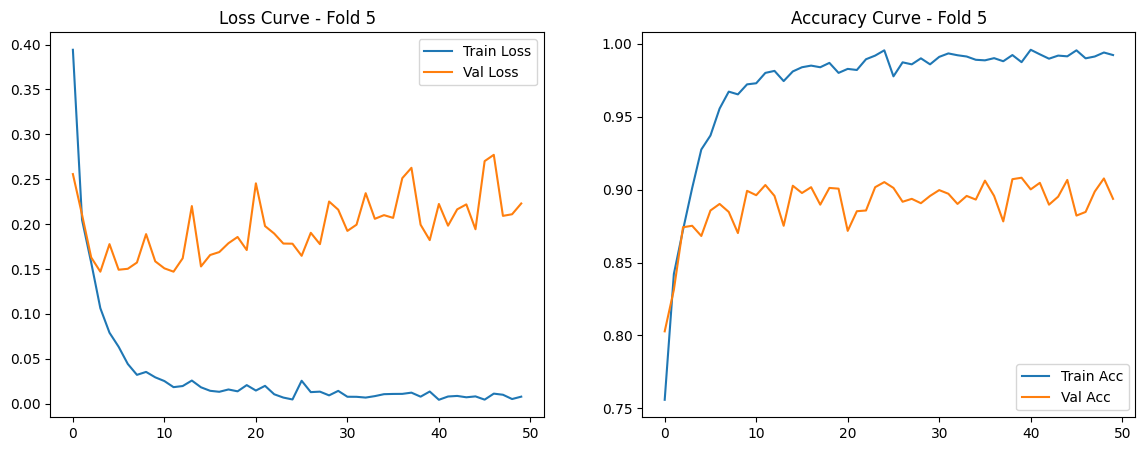

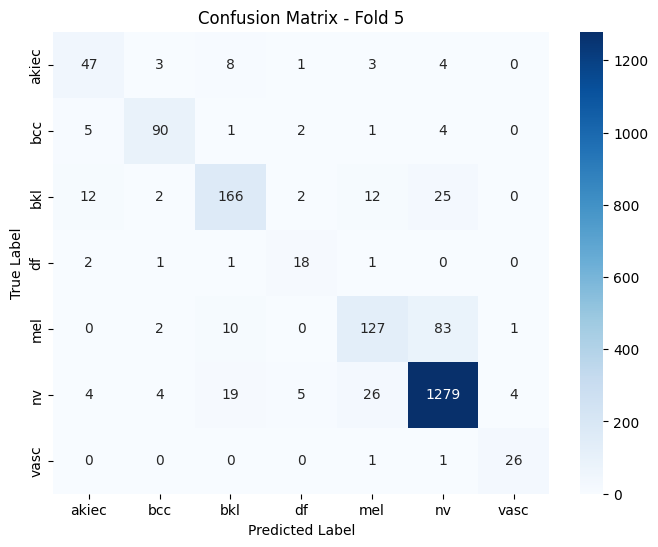

Semua log dan grafik untuk Fold 5 berhasil disimpan di folder: results_exp3

ALHAMDULILLAH, EKSPERIMEN 3 SELESAI TOTAL!
Semua grafik, metric, dan file .pth telah diamankan.


In [7]:
# CELL 7: MASTER EXECUTION LOOP (RUN EXPERIMENT 1)
import torch.optim as optim

# Hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4

print(f"Mulai Eksperimen 3: ConvNeXt + CBAM + Focal Loss")
print(f"Menyimpan di folder: {SAVE_DIR}\n" + "="*50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n---> Memulai Fold {fold} <---")
    
    # Bagi dataframe berdasarkan index fold
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]
    
    # Buat Dataset dan DataLoader
    train_dataset = HAM10000Dataset(train_df, transform=train_transform)
    val_dataset = HAM10000Dataset(val_df, transform=val_transform)
    
    # Gunakan num_workers=4 atau 8 jika CPU Xeon Anda mendukung untuk mempercepat I/O
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Inisialisasi Ulang Model dan Optimizer untuk setiap Fold
    model = ConvNeXt_CBAM_Attention(num_classes=7).to(device)
    criterion = FocalLoss(gamma=2) # Mengatasi Imbalance
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Mulai Training
    history, t_time, max_mem = train_model(
        fold=fold, 
        model=model, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        criterion=criterion, 
        optimizer=optimizer, 
        num_epochs=NUM_EPOCHS
    )
    
    # Mulai Evaluasi & Plotting
    evaluate_and_plot(
        fold=fold, 
        model=model, 
        val_loader=val_loader, 
        history=history, 
        training_time=t_time, 
        max_memory=max_mem, 
        class_names=class_names
    )
    
print("\n" + "="*50)
print("ALHAMDULILLAH, EKSPERIMEN 3 SELESAI TOTAL!")
print("Semua grafik, metric, dan file .pth telah diamankan.")

In [2]:
# CELL 8: SUMMARY CALCULATOR (MEAN & STD) - FIXED VERSION
import os
import pandas as pd
import glob

# Pastikan path folder benar sesuai hasil running tadi
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
results_path = "results_exp3"
csv_files = glob.glob(os.path.join(results_path, "exp3_fold*_classification_report.csv"))

if len(csv_files) < 5:
    print(f"Peringatan: Baru ditemukan {len(csv_files)} file CSV. Pastikan 5 fold sudah selesai running semua.")
else:
    all_reports = []
    
    for file in csv_files:
        # Perbaikan: index_col=0 digunakan agar kolom pertama (nama kelas) jadi index
        df_fold = pd.read_csv(file, index_col=0) 
        all_reports.append(df_fold)
    
    # Gabungkan semua fold
    full_concat = pd.concat(all_reports)
    
    # Hitung rata-rata (Mean) dan Standar Deviasi (Std)
    mean_report = full_concat.groupby(full_concat.index).mean()
    std_report = full_concat.groupby(full_concat.index).std()

    # Mengambil metrik utama (Accuracy dan Macro F1)
    # Note: Di report sklearn, accuracy biasanya ada di baris 'accuracy' kolom 'precision'
    mean_accuracy = mean_report.loc['accuracy', 'precision']
    mean_macro_f1 = mean_report.loc['macro avg', 'f1-score']
    
    std_accuracy = std_report.loc['accuracy', 'precision']
    std_macro_f1 = std_report.loc['macro avg', 'f1-score']
    
    print("="*50)
    print("   HASIL AKHIR EKSPERIMEN 2 (STATISTIK 5-FOLD)")
    print("="*50)
    print(f"Mean Accuracy : {mean_accuracy:.4f} ± {std_accuracy:.4f}")
    print(f"Mean Macro F1 : {mean_macro_f1:.4f} ± {std_macro_f1:.4f}")
    print("-" * 50)
    
    # Tampilkan tabel lengkap rata-rata per kelas agar bisa langsung di-copy ke Paper
    print("\nLaporan Lengkap (Mean Performance per Class):")
    target_rows = class_names + ['macro avg', 'weighted avg']
    summary_table = mean_report.loc[target_rows, ['precision', 'recall', 'f1-score']]
    
    # Menampilkan tabel
    from IPython.display import display
    display(summary_table)
    
    # Simpan hasil akhir ke CSV untuk arsip
    summary_table.to_csv(os.path.join(results_path, "EXP3_FINAL_SUMMARY_STATISTICS.csv"))
    print(f"\n[INFO] Laporan final telah disimpan di: {results_path}/EXP2_FINAL_SUMMARY_STATISTICS.csv")

   HASIL AKHIR EKSPERIMEN 2 (STATISTIK 5-FOLD)
Mean Accuracy : 0.8936 ± 0.0152
Mean Macro F1 : 0.8236 ± 0.0320
--------------------------------------------------

Laporan Lengkap (Mean Performance per Class):


,precision,recall,f1-score
akiec,0.805000,0.678928,0.734135
bcc,0.856775,0.857872,0.857007
bkl,0.785828,0.817053,0.799797
df,0.841098,0.782609,0.803217
mel,0.759979,0.679368,0.715134
nv,0.938822,0.956600,0.947591
vasc,0.918240,0.901724,0.908350
macro avg,0.843677,0.810593,0.823604
weighted avg,0.892154,0.893560,0.891697



[INFO] Laporan final telah disimpan di: results_exp3/EXP2_FINAL_SUMMARY_STATISTICS.csv
